In [1]:

import pandas as pd
import numpy as np
import matplotlib

import matplotlib.pyplot as plt
import os
import mne
print(mne.__version__)
%matplotlib qt

1.11.0


Función de lectura de archivos

In [3]:
def data_reading(filename_eeg):
    ''' Función encargada de leer los archivos de EEG, guardarlos en los formatos adecuados y leer los eventos'''
    
    montage = mne.channels.make_standard_montage('standard_1005')
    montage.ch_names = [element.upper() for element in montage.ch_names]

    eeg_raw = mne.io.read_raw_cnt(filename_eeg, preload=True)
    # Lectura de eventos desde las anotaciones del archivo.
    events_times, events_id = mne.events_from_annotations(eeg_raw)

    # Corrijo las posiciones de los electrodos en el montaje, porque espacialmente están en cualquiera
    # eeg_raw.rename_channels(mapping=dict(Po3='PO3', Fp1='FP1', Fp2='FP2', Fz='FZ', Cz='CZ', Pz='PZ' ))

    eeg_raw.set_montage(montage)

    # unity_data = pd.read_csv(filename_unity, sep=",")

    # return eeg_raw, unity_data, events_times, events_id
    return eeg_raw, events_times, events_id

In [4]:
file_eeg =  os.path.join("pruebas_gorra_miercoles_19_11","piloto_chris2.cnt")


Leo los archivos .cnt, creo los objetos MNE y grafico señal continua con eventos

In [5]:
raw, event_t, event_id = data_reading(file_eeg)

C:\Users\sofip\AppData\Local\Temp\ipykernel_15632\1237900179.py:7: RuntimeWarning:   Could not parse meas date from the header. Setting to None.
  eeg_raw = mne.io.read_raw_cnt(filename_eeg, preload=True)


Reading 0 ... 518839  =      0.000 ...   518.839 secs...
Used Annotations descriptions: ['224']


In [6]:
print(raw.info['sfreq'])

print(raw.info['ch_names'])
print(event_t)

1000.0
['FP1', 'FP2', 'F8', 'F4', 'FZ', 'F3', 'F7', 'FC6', 'FC2', 'FC1', 'FC5', 'T8', 'C4', 'CZ', 'C3', 'T7', 'CP6', 'CP2', 'CP1', 'CP5', 'TP10', 'P8', 'P4', 'PZ', 'P3', 'P7', 'TP9', 'O2', 'O1']
[[ 38678      0      1]
 [ 39132      0      1]
 [ 48822      0      1]
 [ 49332      0      1]
 [ 59180      0      1]
 [ 59634      0      1]
 [ 68768      0      1]
 [ 69234      0      1]
 [ 77380      0      1]
 [ 77862      0      1]
 [ 86781      0      1]
 [ 87238      0      1]
 [ 95281      0      1]
 [ 95763      0      1]
 [105383      0      1]
 [105919      0      1]
 [115882      0      1]
 [116364      0      1]
 [124482      0      1]
 [124981      0      1]
 [134697      0      1]
 [135167      0      1]
 [143696      0      1]
 [144151      0      1]
 [153284      0      1]
 [153796      0      1]
 [162484      0      1]
 [162980      0      1]
 [172484      0      1]
 [172952      0      1]
 [180184      0      1]
 [180680      0      1]
 [191785      0      1]
 [192253     

In [7]:
events_start = event_t.copy()  # matriz Nx3 original
print("Triggers: ",len(event_t))
# quedarse solo con los eventos cada dos muestras
events_start = events_start[0::2]


Triggers:  80


In [10]:
print("N estimulos efectivos",len(events_start))
print(events_start)
np.savetxt('events_28_11.csv', events_start, delimiter=',')

N estimulos efectivos 40
[[ 38678      0      1]
 [ 48822      0      1]
 [ 59180      0      1]
 [ 68768      0      1]
 [ 77380      0      1]
 [ 86781      0      1]
 [ 95281      0      1]
 [105383      0      1]
 [115882      0      1]
 [124482      0      1]
 [134697      0      1]
 [143696      0      1]
 [153284      0      1]
 [162484      0      1]
 [172484      0      1]
 [180184      0      1]
 [191785      0      1]
 [201585      0      1]
 [211298      0      1]
 [222586      0      1]
 [231386      0      1]
 [241275      0      1]
 [250587      0      1]
 [261287      0      1]
 [270188      0      1]
 [279187      0      1]
 [287988      0      1]
 [298876      0      1]
 [307089      0      1]
 [315789      0      1]
 [325591      0      1]
 [334791      0      1]
 [344404      0      1]
 [354302      0      1]
 [362702      0      1]
 [371902      0      1]
 [381103      0      1]
 [390303      0      1]
 [399804      0      1]
 [410104      0      1]]


filtrado de raw

In [28]:
raw.plot()

NOTE: plot_raw_psd() is a legacy function. New code should use Raw.compute_psd().plot().
Effective window size : 2.048 (s)
Plotting power spectral density (dB=True).


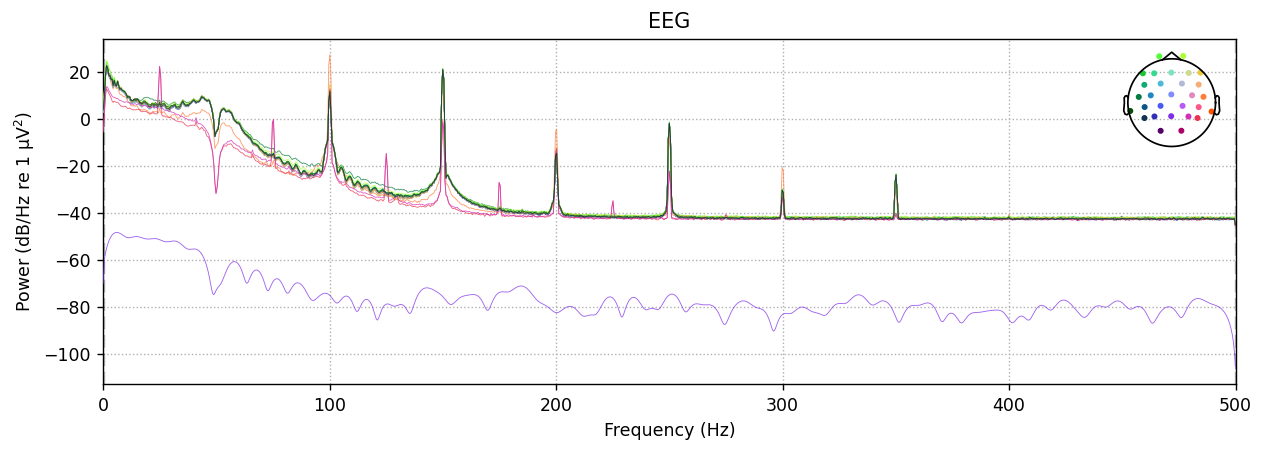

In [29]:
mne.viz.plot_raw_psd(raw)

In [39]:
filt_raw = raw.copy().filter(l_freq = 0.5 , h_freq = 30, method='iir', iir_params={'order': 4, 'ftype': 'butter', 'output': 'sos'})

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 0.5 - 30 Hz

IIR filter parameters
---------------------
Butterworth bandpass zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 16 (effective, after forward-backward)
- Cutoffs at 0.50, 30.00 Hz: -6.02, -6.02 dB



In [40]:
filt_raw.plot()

Channels marked as bad:
none


In [46]:
# Re-referenciado al promedio menos Pz que estaba planchado...
# 1) Excluir Pz,P4,P8 del raw filtrado
raw_noP = filt_raw.copy().drop_channels(['FP1','FP2','T7','PZ','P4','P8'])
#raw_noP = filt_raw.copy().drop_channels(['FP1','FP2','P4'])


# 2) Re-referenciar con el promediopromedio (sin canales malos)
ref_raw = raw_noP.copy().set_eeg_reference(ref_channels='average')


EEG channel type selected for re-referencing
Applying average reference.
Applying a custom ('EEG',) reference.


In [23]:
ref_raw.plot()

Channels marked as bad:
none


Epocas (fragmentos) creados con t=0 dado con el primer trigger

In [47]:

epochs = mne.Epochs(
    ref_raw,
    events=events_start[:-5],
    tmin=-0.2,
    tmax=0.8,
    baseline=(-0.2, 0),
    preload=True
)


Not setting metadata
35 matching events found
Applying baseline correction (mode: mean)
0 projection items activated
Using data from preloaded Raw for 35 events and 1001 original time points ...
0 bad epochs dropped


#-- Visualizacion de epocas -->

In [44]:
N_epochs = len(epochs)
print("epocas:",N_epochs)

epocas: 35


In [47]:
epochs.plot?


Signature:
epochs.plot(
    picks=None,
    scalings=None,
    n_epochs=20,
    n_channels=20,
    title=None,
    events=False,
    event_color=None,
    order=None,
    show=True,
    block=False,
    decim='auto',
    noise_cov=None,
    butterfly=False,
    show_scrollbars=True,
    show_scalebars=True,
    epoch_colors=None,
    event_id=None,
    group_by='type',
    precompute=None,
    use_opengl=None,
    *,
    theme=None,
    overview_mode=None,
    splash=True,
)
Docstring:
Visualize epochs.

Bad epochs can be marked with a left click on top of the epoch. Bad
channels can be selected by clicking the channel name on the left side of
the main axes. Calling this function drops all the selected bad epochs as
well as bad epochs marked beforehand with rejection parameters.

Parameters
----------
picks : str | array-like | slice | None
    Channels to include. Slices and lists of integers will be interpreted as 
    channel indices. In lists, channel *type* strings (e.g., ``['meg'

In [ ]:
epochs.plot(n_epochs=4)


Dropped 1 epoch: 20
The following epochs were marked as bad and are dropped:
[20]
Channels marked as bad:
none


In [30]:
evoked.plot?

Signature:
evoked.plot(
    picks=None,
    exclude='bads',
    unit=True,
    show=True,
    ylim=None,
    xlim='tight',
    proj=False,
    hline=None,
    units=None,
    scalings=None,
    titles=None,
    axes=None,
    gfp=False,
    window_title=None,
    spatial_colors='auto',
    zorder='unsorted',
    selectable=True,
    noise_cov=None,
    time_unit='s',
    sphere=None,
    *,
    highlight=None,
    verbose=None,
)
Docstring:
Plot evoked data using butterfly plots.

Left click to a line shows the channel name. Selecting an area by clicking
and holding left mouse button plots a topographic map of the painted area.

.. note:: If bad channels are not excluded they are shown in red.

Parameters
----------
picks : str | array-like | slice | None
    Channels to include. Slices and lists of integers will be interpreted as 
    channel indices. In lists, channel *type* strings (e.g., ``['meg', 
    'eeg']``) will pick channels of those types, channel *name* strings (e.g., 
    

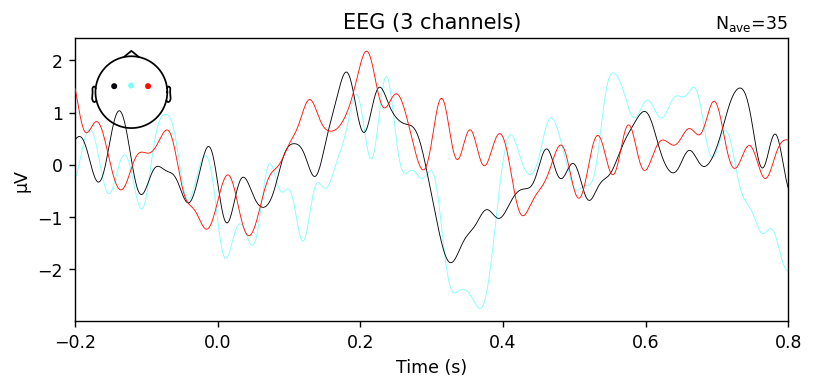

In [50]:
evoked = epochs.average()
#evoked.plot()
evoked.plot(picks=['CZ','C3','C4'])

In [18]:
for epoch in epochs.get_data(picks='CZ'):
    plt.plot(epoch)